In [ ]:
import pandas as pd

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income"
]

df = pd.read_csv(
    "adult.csv",
    header=None,
    names=columns,
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.select_dtypes(include="object").columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

cat_features = X.select_dtypes(include=["object"]).columns.tolist()

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric="AUC",
    random_state=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	test: 0.8834327	best: 0.8834327 (0)	total: 267ms	remaining: 2m 13s
100:	test: 0.9284968	best: 0.9284968 (100)	total: 12s	remaining: 47.2s
200:	test: 0.9310365	best: 0.9310370 (197)	total: 26.3s	remaining: 39.1s
300:	test: 0.9315579	best: 0.9315955 (299)	total: 45.7s	remaining: 30.2s
400:	test: 0.9318992	best: 0.9319403 (392)	total: 53.7s	remaining: 13.3s
499:	test: 0.9318091	best: 0.9319718 (409)	total: 1m 7s	remaining: 0us

bestTest = 0.9319718312
bestIteration = 409

Shrink model to first 410 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.1, random_state=42, verbose=100)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds, pos_label=">50K"))
print("Recall:", recall_score(y_test, preds, pos_label=">50K"))
print("F1:", f1_score(y_test, preds, pos_label=">50K"))
print("ROC-AUC:", roc_auc_score((y_test==">50K").astype(int), probs))

Accuracy: 0.8797215682260211
Precision: 0.7959287531806616
Recall: 0.6689478186484175
F1: 0.7269346967232163
ROC-AUC: 0.931971831180479


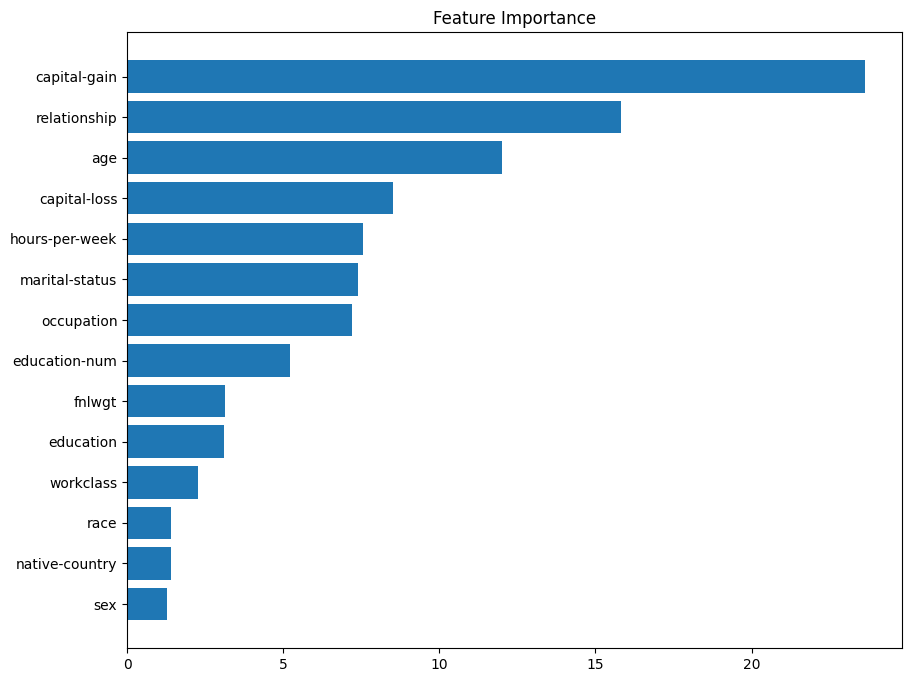

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.get_feature_importance()
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

In [ ]:
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_enc, y_train)

pred = model.predict(X_test_enc)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8458388780837343


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model_adv = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.01,
    depth=6,
    early_stopping_rounds=50,
    eval_metric="AUC",
    verbose=100
)

model_adv.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	test: 0.8753258	best: 0.8753258 (0)	total: 192ms	remaining: 6m 23s
100:	test: 0.9119347	best: 0.9119347 (100)	total: 11.3s	remaining: 3m 32s
200:	test: 0.9162443	best: 0.9162443 (200)	total: 19.8s	remaining: 2m 57s
300:	test: 0.9200090	best: 0.9200090 (300)	total: 28.6s	remaining: 2m 41s
400:	test: 0.9220734	best: 0.9220734 (400)	total: 36.3s	remaining: 2m 24s
500:	test: 0.9240349	best: 0.9240349 (500)	total: 48.8s	remaining: 2m 25s
600:	test: 0.9252572	best: 0.9252572 (600)	total: 1m 1s	remaining: 2m 22s
700:	test: 0.9258935	best: 0.9258935 (700)	total: 1m 9s	remaining: 2m 9s
800:	test: 0.9266453	best: 0.9266453 (800)	total: 1m 17s	remaining: 1m 55s
900:	test: 0.9270865	best: 0.9270865 (900)	total: 1m 25s	remaining: 1m 44s
1000:	test: 0.9276923	best: 0.9276923 (999)	total: 1m 33s	remaining: 1m 33s
1100:	test: 0.9282028	best: 0.9282045 (1099)	total: 1m 42s	remaining: 1m 23s
1200:	test: 0.9287008	best: 0.9287008 (1200)	total: 1m 53s	remaining: 1m 15s
1300:	test: 0.9292476	best: 0.929

CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=2000, learning_rate=0.01, verbose=100)